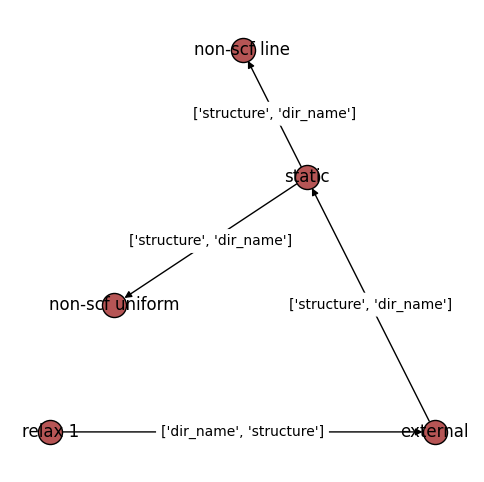

In [5]:
from fireworks import LaunchPad
from atomate2.vasp.flows.core import RelaxBandStructureMaker
from atomate2.vasp.powerups import add_metadata_to_flow
from jobflow.managers.fireworks import flow_to_workflow
from pymatgen.core import Structure

# construct a rock salt MgO structure
mgo_structure = Structure(
    lattice=[[0, 2.13, 2.13], [2.13, 0, 2.13], [2.13, 2.13, 0]],
    species=["Mg", "O"],
    coords=[[0, 0, 0], [0.5, 0.5, 0.5]],
)

# make a band structure flow to optimise the structure and obtain the band structure
bandstructure_flow = RelaxBandStructureMaker().make(mgo_structure)
#show diagram of the flow
bandstructure_flow.draw_graph(figsize=(6, 6)).show()

In [ ]:
# (Optional) add metadata to the flow task document.
# Could be useful to filter specific results from the database.
# For e.g., adding material project ID for the compound, use following lines
bandstructure_flow = add_metadata_to_flow(
    flow=bandstructure_flow,
    additional_fields={"mp_id": "mp-190"},
)
#set the name of the worker to the name you set in my_fworker.yaml
worker = "my_fworker"

bandstructure_flow.update_config({"manager_config": {"_fworker": worker}})

# convert the flow to a fireworks WorkFlow object
wf = flow_to_workflow(bandstructure_flow)

# submit the workflow to the FireWorks launchpad
lpad = LaunchPad.from_file("../my_launchpad.yaml")  
lpad.add_wf(wf)